In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import warnings

warnings.filterwarnings("ignore")

from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    ExtraTreesRegressor,
)
from sklearn.linear_model import ElasticNetCV
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, RandomizedSearchCV

# from utils.utils import *
from utils.data_loader import load_data
from utils.random_forest import RF_data_prep

# Loading data

In [3]:
final_clean_strained = load_data(db_level=0)

In [4]:
peak_curvs = final_clean_strained["PeakI Curvature"].apply(pd.Series)
peak_curvs.columns = [
    "PeakI Left Curvature",
    "PeakI Overall Curvature",
    "PeakI Right Curvature",
]
trough_curvs = final_clean_strained["TroughI Curvature"].apply(pd.Series)
trough_curvs.columns = [
    "TroughI Left Curvature",
    "TroughI Overall Curvature",
    "TroughI Right Curvature",
]
final_clean_strained = pd.concat(
    [final_clean_strained, peak_curvs, trough_curvs], axis=1
)

In [5]:
def split_by_mouse(
    data,
    split_on="Subject",
    stratify_on="Group",
    test_size=0.2,
    val_size=0.18,
    random_state=22,
    return_idx=False,
):
    mice = data[[split_on, stratify_on]].drop_duplicates().set_index(split_on)

    train, test = train_test_split(
        mice.index,
        test_size=test_size,
        shuffle=True,
        stratify=mice[stratify_on],
        random_state=random_state,
    )

    train_indices = data[split_on].isin(train)
    test_indices = data[split_on].isin(test)

    train2, val = train_test_split(
        train,
        test_size=val_size,
        shuffle=True,
        stratify=mice.loc[train]["Group"],
        random_state=random_state,
    )

    train2_indices = data[split_on].isin(train2)
    val_indices = data[split_on].isin(val)

    data["DataGroup"] = ""
    data.loc[train2_indices, "DataGroup"] = "Train"
    data.loc[val_indices, "DataGroup"] = "Validate"
    data.loc[test_indices, "DataGroup"] = "Test"
    if return_idx:
        return data, train_indices, train2_indices, val_indices, test_indices
    return data

# Train test split

In [28]:
final_clean_strained_70 = final_clean_strained[
    (final_clean_strained["Level(dB)"] == 70) & (final_clean_strained["Level(dB)"] < 80)
]
final_clean_strained_70 = split_by_mouse(final_clean_strained_70)
num_features = [
    "Frequency(kHz)",
    "Amplitude",
    "Slope",
    "Total Variance",
    "Distance",
    "Noise",
    "Time (hrs)",
    "PeakI Left Curvature",
    "PeakI Overall Curvature",
    "PeakI Right Curvature",
    "TroughI Left Curvature",
    "TroughI Overall Curvature",
    "TroughI Right Curvature",
    "Level(dB)",
]
cat_features = ["vx", "Strain (binary)"]
X_train, X_test, y_train, y_test, preprocessor = RF_data_prep(
    final_clean_strained_70, num_features, cat_features
)

# Elastic Net

In [29]:
smf_df = final_clean_strained_70.copy()
smf_df.columns = [
    "Subject",
    "Frequency",
    "Level",
    "Amplitude",
    "vx",
    "SynapsesPerIHC",
    "IHCs",
    "OrphansPerIHC",
    "Waveform",
    "WaveI",
    "Peaks",
    "Troughs",
    "Slope",
    "TotalVariance",
    "Distance",
    "PeakICurvature",
    "TroughICurvature",
    "Strain",
    "Sex",
    "Group",
    "Noise",
    "Time(str)",
    "Time_hrs",
    "Strain_b",
    "PeakILeftCurvature",
    "PeakIOverallCurvature",
    "PeakIRightCurvature",
    "TroughILeftCurvature",
    "TroughIOverallCurvature",
    "TroughIRightCurvature",
    "DataGroup",
]

In [30]:
import statsmodels.formula.api as smf

model = smf.ols(
    "SynapsesPerIHC ~ Frequency + Amplitude + TotalVariance + Distance + Noise + Time_hrs + PeakILeftCurvature + PeakIOverallCurvature + PeakIRightCurvature + TroughILeftCurvature + TroughIOverallCurvature + TroughIRightCurvature + C(vx) + C(Strain_b)",
    data=smf_df,
).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:         SynapsesPerIHC   R-squared:                       0.316
Model:                            OLS   Adj. R-squared:                  0.308
Method:                 Least Squares   F-statistic:                     41.26
Date:                Thu, 13 Nov 2025   Prob (F-statistic):           6.19e-93
Time:                        13:23:06   Log-Likelihood:                -3119.2
No. Observations:                1268   AIC:                             6268.
Df Residuals:                    1253   BIC:                             6346.
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
===========================================================================================
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                  16.4166      0.600     27.363      0.000      15.240      17.594
C(vx)[T.v2]                 0.0346      0.160      0.216      0.829      -0.279       0.349
C(Strain_b)[T.1]            1.3680      0.232      5.902      0.000       0.913       1.823
Frequency                  -0.0242      0.007     -3.553      0.000      -0.038      -0.011
Amplitude                   2.3726      0.548      4.327      0.000       1.297       3.448
TotalVariance              -0.2811      0.071     -3.967      0.000      -0.420      -0.142
Distance                   -1.2180      0.391     -3.115      0.002      -1.985      -0.451
Noise                      -2.4569      0.260     -9.465      0.000      -2.966      -1.948
Time_hrs                   -0.0161      0.004     -4.590      0.000      -0.023      -0.009
PeakILeftCurvature         -0.0028      0.011     -0.250      0.803      -0.024       0.019
PeakIOverallCurvature      -0.0014      0.003     -0.421      0.674      -0.008       0.005
PeakIRightCurvature        -0.0865      0.012     -7.232      0.000      -0.110      -0.063
TroughILeftCurvature       -0.0196      0.008     -2.337      0.020      -0.036      -0.003
TroughIOverallCurvature    -0.0017      0.003     -0.518      0.605      -0.008       0.005
TroughIRightCurvature      -0.0028      0.006     -0.433      0.665      -0.015       0.010
==============================================================================
Omnibus:                       68.868   Durbin-Watson:                   1.143
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               94.800
Skew:                          -0.485   Prob(JB):                     2.60e-21
Kurtosis:                       3.923   Cond. No.                         658.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [22]:
pipeline = Pipeline(
    [
        ("preprocessor", preprocessor),
        ("elasticnet_cv", ElasticNetCV(alphas=[1e-3, 1e-2, 1e-1, 1, 10], cv=5)),
    ]
)
pipeline.fit(X_train, y_train)
print(f"Elastic Net training set score: {pipeline.score(X_train, y_train)}")
print(f"Elastic Net test set score: {pipeline.score(X_test, y_test)}")

Elastic Net training set score: 0.29336997125061226
Elastic Net test set score: 0.3553340148031655


# Random Forest

In [23]:
rf_params = {
    "rf__n_estimators": [25, 50, 100, 150, 200, 300, 400, 500],
    "rf__max_depth": [5, 10, 20, 30, 40, None],
    "rf__min_samples_leaf": [2, 5, 10, 15, 20, 30],
    "rf__min_samples_split": [2, 5, 10, 15, 20, 30],
    "rf__max_features": ["sqrt", "log2", 0.3, 0.5],
}

rf_pipeline = Pipeline(
    [("preprocessor", preprocessor), ("rf", RandomForestRegressor(random_state=1))]
)

# Use RandomizedSearchCV for efficiency
rf_search = RandomizedSearchCV(
    rf_pipeline,
    rf_params,
    cv=5,
    scoring="r2",
    random_state=1,
    n_jobs=-1,
)
rf_search.fit(X_train, y_train)
print(f"Best RF params: {rf_search.best_params_}")
r2 = rf_search.score(X_test, y_test)
print(f"Best RF score: {rf_search.best_score_:.3f}, R2 on test set: {r2:.3f}")
best_rf_model = rf_search.best_estimator_

Best RF params: {'rf__n_estimators': 50, 'rf__min_samples_split': 30, 'rf__min_samples_leaf': 2, 'rf__max_features': 0.5, 'rf__max_depth': 5}
Best RF score: 0.444, R2 on test set: 0.684


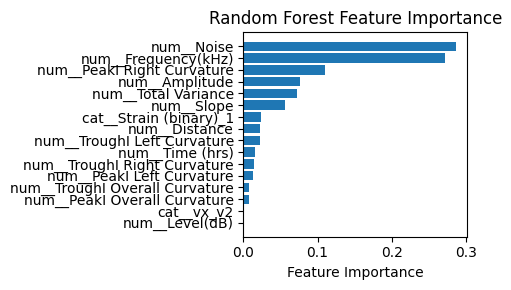

In [24]:
# Get feature importance
feature_importance = best_rf_model.named_steps["rf"].feature_importances_
feature_names = best_rf_model.named_steps["preprocessor"].get_feature_names_out()

importance_df = pd.DataFrame(
    {"Feature": feature_names, "Importance": feature_importance}
).sort_values("Importance", ascending=False)

plt.figure(figsize=(5, 3))
plt.barh(range(len(importance_df)), importance_df["Importance"])
plt.yticks(range(len(importance_df)), importance_df["Feature"])
plt.xlabel("Feature Importance")
plt.title("Random Forest Feature Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [12]:
def plot_results(x, y, alpha=0.2, markersize=5, title="", color=None):
    if color is None:
        color = np.random.rand(
            3,
        )
        while np.mean(color) > 0.6:
            color = np.random.rand(
                3,
            )
    plt.plot(x, y, "o", alpha=alpha, markersize=markersize, color=color)
    plt.plot([5, 20], [5, 20], "k--", alpha=0.5)
    plt.axis("square")
    plt.xticks(np.arange(5, 21, 5))
    plt.yticks(np.arange(5, 21, 5))
    plt.xlim(5, 20)
    plt.ylim(5, 20)
    plt.title(title)
    plt.xlabel("GT # Synapses")
    plt.ylabel("Predicted # Synapses")

In [13]:
def train_plot_result(df, rf_pipeline):
    df = split_by_mouse(df)
    num_features = [
        "Frequency(kHz)",
        "Amplitude",
        "Slope",
        "Total Variance",
        "Distance",
        "Noise",
        "Time (hrs)",
        "Level(dB)",
        "PeakI Left Curvature",
        "PeakI Overall Curvature",
        "PeakI Right Curvature",
        "TroughI Left Curvature",
        "TroughI Overall Curvature",
        "TroughI Right Curvature",
    ]
    cat_features = ["Strain (binary)"]
    if len(df["vx"]) > 1:
        cat_features.append("vx")
    X_train, X_test, y_train, y_test, preprocessor = RF_data_prep(
        df, num_features, cat_features
    )
    dB_bins = [10, 20, 30, 40, 50, 60, 70, 80]
    # rf_pipeline = best_rf_model
    plt.figure(figsize=(10, 4))

    color_palette = plt.cm.get_cmap("tab10", len(dB_bins) + 2)
    # iterate over dB levels:
    for dB in dB_bins:
        features = num_features + cat_features
        data = df[(df["Level(dB)"] >= dB) & (df["Level(dB)"] < dB + 10)]
        X = data[features]
        y = data["SynapsesPerIHC"]
        X_train1, X_test1, y_train1, y_test1 = (
            X[data.DataGroup != "Test"],
            X[data.DataGroup == "Test"],
            y[data.DataGroup != "Test"],
            y[data.DataGroup == "Test"],
        )
        if len(X_train1) > 0 and len(X_test1) > 0:
            rf_pipeline.fit(X_train1, y_train1)
            r2 = rf_pipeline.score(X_test1, y_test1)
            rmse = np.sqrt(np.mean((y_test1 - rf_pipeline.predict(X_test1)) ** 2))
            print(
                f"{dB}-{dB + 5} dB, {len(data)} samples, R2: {r2:.3f}, RMSE: {rmse:.3f}"
            )
            plt.subplot(2, 5, dB // 10)
            plot_results(
                y_test1,
                rf_pipeline.predict(X_test1),
                title=f"{dB}-{dB + 5} dB",
                color=color_palette(dB // 10 - 1),
            )
            # show R2 in lower right corner of plot:
            plt.text(
                19.75,
                5,
                f"R2: {r2:.2f}",
                fontsize=10,
                horizontalalignment="right",
                verticalalignment="bottom",
            )

    # run on all data:
    rf_pipeline.fit(X_train, y_train)
    r2 = rf_pipeline.score(X_test, y_test)
    rmse = np.sqrt(np.mean((y_test - rf_pipeline.predict(X_test)) ** 2))
    print(f"All data, {len(df)} samples, R2: {r2:.3f}, RMSE: {rmse:.3f}")
    plt.subplot(2, 5, 9)
    plot_results(
        y_test,
        rf_pipeline.predict(X_test),
        alpha=0.05,
        title=f"All",
        color=color_palette(-2),
    )
    plt.text(
        19.75,
        5,
        f"R2: {r2:.2f}",
        fontsize=10,
        horizontalalignment="right",
        verticalalignment="bottom",
    )

    test_set = df[df["DataGroup"] == "Test"]
    test_set["RF predictions"] = rf_pipeline.predict(X_test)

    plt.text(
        19.75,
        5,
        f"R2: {r2:.2f}",
        fontsize=10,
        horizontalalignment="right",
        verticalalignment="bottom",
    )

    plt.tight_layout()
    plt.show()

Best RF score: 0.774, R2 on test set: 0.675
10-15 dB, 1126 samples, R2: 0.305, RMSE: 2.017
20-25 dB, 1796 samples, R2: 0.386, RMSE: 1.829
30-35 dB, 1868 samples, R2: 0.443, RMSE: 1.937
40-45 dB, 1653 samples, R2: 0.429, RMSE: 2.085
50-55 dB, 1496 samples, R2: 0.537, RMSE: 2.211
60-65 dB, 1488 samples, R2: 0.639, RMSE: 2.302
70-75 dB, 1492 samples, R2: 0.736, RMSE: 2.091
80-85 dB, 1268 samples, R2: 0.665, RMSE: 2.104
All data, 12187 samples, R2: 0.671, RMSE: 1.854


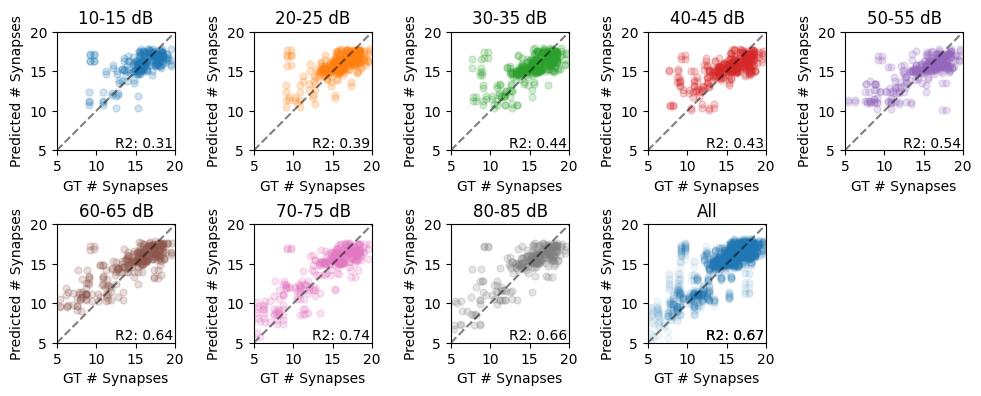

In [35]:
rf_pipeline = Pipeline(
    [
        ("preprocessor", preprocessor),
        (
            "rf",
            RandomForestRegressor(
                random_state=1,
                n_estimators=50,
                min_samples_split=30,
                min_samples_leaf=2,
                max_features=0.5,
                max_depth=30,
            ),
        ),
    ]
)
rf_pipeline.fit(X_train, y_train)
r2 = rf_pipeline.score(X_test, y_test)
print(
    f"Best RF score: {rf_pipeline.score(X_train, y_train):.3f}, R2 on test set: {r2:.3f}"
)
train_plot_result(final_clean_strained, rf_pipeline)

In [46]:
rf = RandomForestRegressor(
    random_state=1,
    n_estimators=50,
    min_samples_split=30,
    min_samples_leaf=2,
    max_features=0.5,
    max_depth=30,
).fit(preprocessor.transform(X_train), y_train)

In [47]:
tree_depth = [t.tree_.max_depth for t in rf.estimators_]
np.max(tree_depth)

21

10-15 dB, 1126 samples, R2: 0.305, RMSE: 2.017
20-25 dB, 1796 samples, R2: 0.375, RMSE: 1.845
30-35 dB, 1868 samples, R2: 0.429, RMSE: 1.961
40-45 dB, 1653 samples, R2: 0.416, RMSE: 2.109
50-55 dB, 1496 samples, R2: 0.519, RMSE: 2.252
60-65 dB, 1488 samples, R2: 0.637, RMSE: 2.311
70-75 dB, 1492 samples, R2: 0.731, RMSE: 2.111
80-85 dB, 1268 samples, R2: 0.649, RMSE: 2.152
All data, 12187 samples, R2: 0.625, RMSE: 1.979


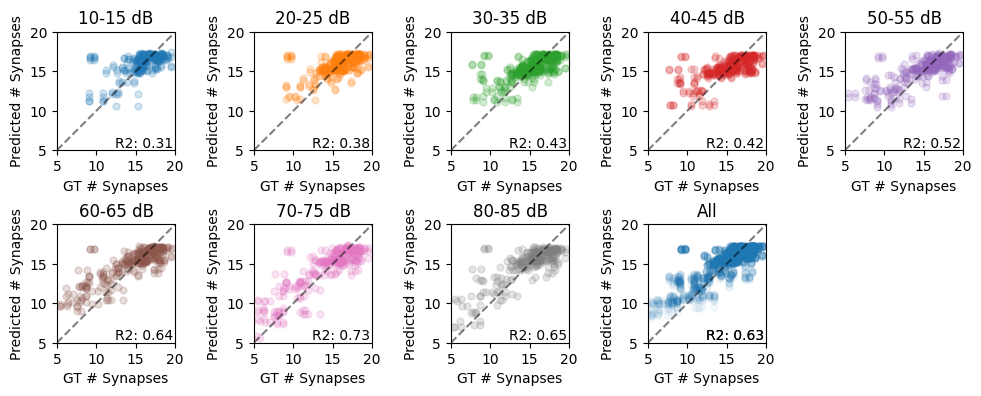

In [25]:
train_plot_result(final_clean_strained, best_rf_model)

In [ ]:
final_clean_strained_avg = (
    final_clean_strained.groupby(["Subject", "Frequency(kHz)", "Level(dB)"])
    .agg(
        {
            "Amplitude": "mean",
            "vx": "first",
            "SynapsesPerIHC": "mean",
            "IHCs": "mean",
            "OrphansPerIHC": "mean",
            "Waveform": "first",
            "WaveI": "first",
            "Peaks": "first",
            "Troughs": "first",
            "Strain": "first",
            "Sex": "first",
            "Group": "first",
            "Noise": "mean",
            "Time (str)": "first",
            "Time (hrs)": "first",
            "Strain (binary)": "first",
            "PeakI Left Curvature": "first",
            "PeakI Overall Curvature": "first",
            "PeakI Right Curvature": "first",
            "TroughI Left Curvature": "first",
            "TroughI Overall Curvature": "first",
            "TroughI Right Curvature": "first",
            "Slope": "first",
            "Total Variance": "first",
            "Distance": "first",
        }
    )
    .reset_index()
)